# Lab 048 · DCNv2
## Build explicit feature crosses; keep the evidence honest.

[Lesson](../lessons/0048-dcnv2.html) · [Reproduction card](../reference/dcnv2-reproduction.html) · [Wang et al., arXiv v2 / WWW 2021](https://arxiv.org/html/2008.13535v2)

**Your skill:** trace a row through a cross network, implement its defining operations, and distinguish model fidelity from score reproduction.

**From L047:** SAINT let a row read companions. DCNv2 learns interactions inside one row. The original row representation stays available to every cross layer.

**Route:** recall → four focused implementation tasks → inspect a real row → train four arms on three real tables → interpret uncertainty → audit a full-data MovieLens attempt → run the paper-results next step.

PROVIDED = read and run. TODO = implement the blanks. CHECK = run immediately; failures explain what to inspect. EXIT = supply your actual evidence and reasoning. The author comparison ran in about 11 seconds on CPU; reading and implementing take much longer. The full MovieLens closer track took about 204 training seconds here; hardware changes runtime.

All nine figures are embedded PNGs in Colab's inline-data format, so they require no code execution or image downloads. Student outputs are intentionally empty. Panels marked **author reference** show a recorded run, not your kernel's results. Local PNG/HTML integrity is checked; live Colab and browser rendering were not checked.

### Reproduction contract

| Track | What you build / run | Boundary |
|---|---|---|
| Eq.1 / Fig.1 | Full supervised dense cross network, row embeddings, parallel/stacked paths, MLP and trainer | PyTorch implementation; original TensorFlow training parity not claimed |
| Eq.2 | Linear factorized cross and an exact dense-equivalence test | Direct factor training is different from post-training compression |
| Eqs.3–4 | Nonlinear experts with tanh and softmax gates | Mechanism + gradient checks; DCN-Mix benchmark results not reproduced |
| Tier A local | `credit_g`, `diabetes`, `blood_transfusion`; 3 seeds; fixed splits | Substitute tables, small untuned budgets; not the paper's Table 6 |
| Tier A paper dataset | MovieLens 1M binary task, full-data closer run and larger presets | Different split and chosen settings; an **INCOMPARABLE** attempt |

The paper's Criteo and private production results are outside this notebook. MovieLens is included, with ratings 3 removed and ratings 1/2 vs 4/5 mapped to 0/1. We do not substitute the TensorFlow tutorial's raw-rating RMSE task.

Model and split seeds are separate. Preprocessing fits training rows only. Validation selects checkpoints. Test labels score frozen predictions; do not change model settings after looking at test scores. Record package versions, exact configuration and output artifacts with your EXIT.

### Cold recall · write before reading the recap

1. What does a residual connection preserve?
2. Why could changing companion rows change SAINT's prediction in evaluation mode?
3. Predict: can greater representational freedom make held-out performance worse under a fixed training budget?

**Your answers:** _write here._

## 1 · Concept recap: multiply by the original input

A **feature cross** is an interaction such as $x_1x_2$: the influence of one feature depends on another. A linear score can add effects; it needs a product feature to express this multiplicative dependence directly.

Categorical **embeddings** are learned vectors indexed by category IDs. Concatenate embeddings and normalized numerical values into one row vector $x_0$ of width $d$. No CLS token is used. After layer $l$, the current representation is $x_l$. The original $x_0$ stays fixed throughout this row's cross stack.

The basic cross operation (paper §3.2 Eq.1) is

$$x_{l+1}=x_l+x_0\odot(W_lx_l+b_l).$$

Here $W_l$ has shape $[d,d]$, $b_l$ has shape $[d]$, and $\odot$ multiplies corresponding coordinates. Mix the current state, multiply by the original input, add the current residual. **Bias is inside the multiplication.** With row batches $[B,d]$, PyTorch stores a linear weight as `[out,in]`, so the affine operation uses the transpose of the stored matrix.

**Worked micro-example:** take $x_0=x_l=[1,2]$, W with rows `[2,-1]`, `[0.5,1]`, and $b=[1,0]$. The affine mixture is `[1,2.5]`; the elementwise update is `[1,5]`; the residual gives `[2,7]`. On coordinate 1, the product includes a contribution from $x_1x_2$ weighted by −1. A zero in W suppresses that direct contribution, not necessarily every path involving that feature.

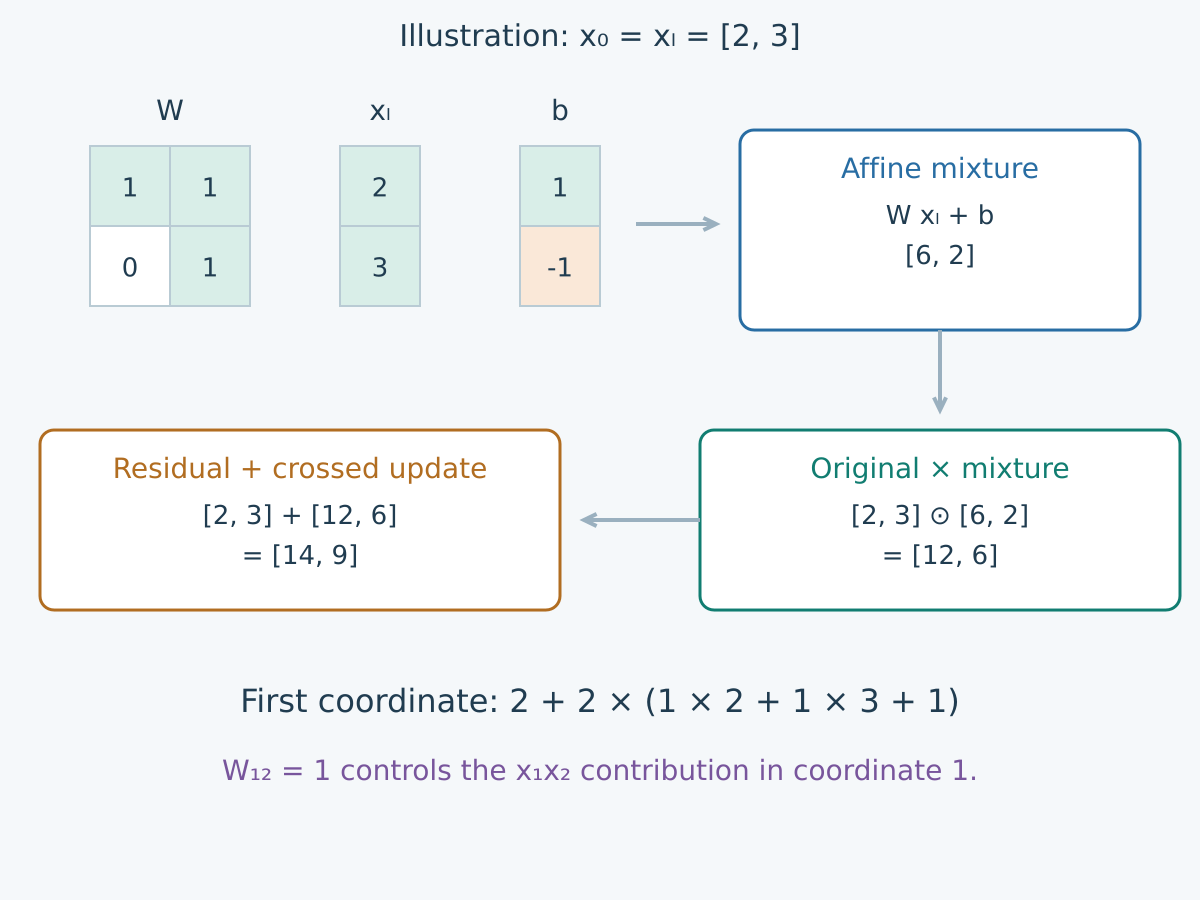

**Mechanism illustration, not training evidence.** This diagram uses the lesson example `[2,3]`, different from the recap: the default output is `[14,9]`. Each intermediate is displayed in computation order. Change W₁₂ in the interactive lesson to see only the first coordinate respond.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

In [ ]:
# PROVIDED — environment and reporting; first code cell above is the Colab bootstrap.
import os, sys, json, copy, hashlib, inspect, platform, time
from pathlib import Path
os.environ.setdefault('OMP_NUM_THREADS','1')
os.environ.setdefault('MPLCONFIGDIR','/tmp/relational-matplotlib')
for candidate in (Path.cwd(),Path.cwd().parent,Path.cwd()/'labs'):
    if (candidate/'relkit').is_dir():
        LABS=candidate.resolve();sys.path.insert(0,str(LABS));break
else:
    raise RuntimeError('Open from repo root, labs/, or labs/solutions/, or run the Colab bootstrap.')
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import log_loss, roc_auc_score
from relkit.saint_experiment import prepare, environment
from relkit.benchmark_report import score_table, plot_scores, plot_ranks, plot_scaleup
torch.set_num_threads(1)
torch.manual_seed(48)
checks={}
def check(name,condition,hint):
    checks[name]=bool(condition)
    assert checks[name], name+': '+hint
    print('PASS ·',name)
display(pd.Series(environment()['versions'],name='Installed version').to_frame())
print('Local learning lab: CPU | architecture:',platform.machine())

## 2 · Task 1 — the dense cross update (Eq.1)

**Goal:** implement the affine mixture and the anchored multiplicative residual.
**Why:** the function can have the right shape while using the wrong bias placement or matrix orientation.
**Hint boundary:** every row needs the same learned coordinate mixtures; each output coordinate multiplies the corresponding *original* coordinate. Both inputs have shape `[B,d]`. Do not detach either path from autograd.

Predict what happens if an original coordinate is zero but the current coordinate is nonzero.

In [ ]:
# TODO — Task 1: two focused expressions
def cross_step(x0, x, weight, bias):
    mixture = ____
    return ____

In [ ]:
# CHECK — non-symmetric weights, bias placement, zeros, and derivatives
x0=torch.tensor([[1.,2.],[0.,-1.]],dtype=torch.float64,requires_grad=True)
x=torch.tensor([[3.,4.],[2.,1.]],dtype=torch.float64,requires_grad=True)
w=torch.tensor([[1.,2.],[-1.,3.]],dtype=torch.float64,requires_grad=True)
b=torch.tensor([.5,-.5],dtype=torch.float64,requires_grad=True)
out=cross_step(x0,x,w,b)
check('Dense numerical result',torch.allclose(out,torch.tensor([[14.5,21.],[2.,.5]],dtype=torch.float64)),
      'Check W orientation, the inner bias, and which input is the residual.')
check('Zero original coordinate',out[1,0]==x[1,0],'Zero original coordinate removes this update, not the current residual.')
check('Dense derivatives',torch.autograd.gradcheck(cross_step,(x0,x,w,b)),
      'Keep the paths through x0, x, W and b connected.')
check('Bias scaling',torch.allclose(cross_step(x0,x,w*0,b),x+x0*b),'The original input scales the bias.')
display(pd.DataFrame(out.detach().numpy(),columns=['coordinate 0','coordinate 1']))

### Why the original input must remain fixed

A **polynomial degree** counts total exponents: $x_1^2x_2$ has degree three. A linear mixture cannot increase degree; multiplication by one coordinate of $x_0$ increases it by at most one. Starting at degree one, $L$ basic cross layers therefore give degree at most $L+1$ in **embedding coordinates**.

The scalar example below uses every weight 1 and every bias 0. The recurrence becomes $x_l=x(1+x)^l$. This is a diagnostic example, not the general model formula. Changing the anchor to the current state would change both the calculation and the degree growth. A nonlinear MLP/readout or mixture does not inherit the bound.

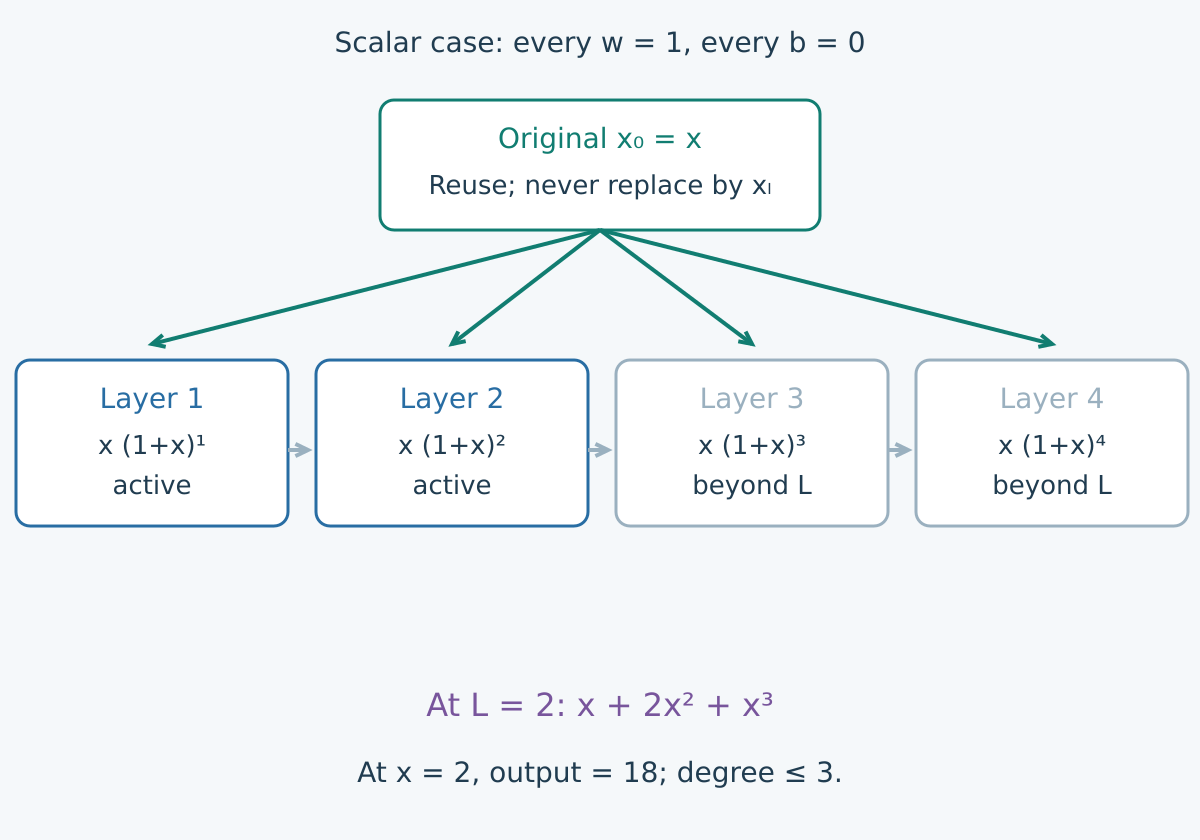

**Read the fixed green input.** At two active layers, the scalar polynomial is `x + 2x² + x³`. At x=2 its value is 18. The gray layers illustrate later depths; they are beyond the chosen L=2.

In [ ]:
# CHECK + prediction — demonstrate the anchor without training anything
original=torch.tensor([[2.]])
state=original
for _ in range(2):
    state=cross_step(original,state,torch.ones(1,1),torch.zeros(1))
check('Two-layer anchor',torch.allclose(state,torch.tensor([[18.]])),
      'Keep the same original input at layer two; replacing it gives 42.')
print('Two anchored layers:',state.item())

**Explain before continuing:** why is degree counted in x₀ rather than in integer category IDs? Why does “at most three” not mean every cubic coefficient is independent?

**Your explanation:** _write here._

## 3 · Task 2 — a low-rank cross (Eq.2)

**Goal:** compute the same update through two factors without materializing a d-by-d matrix.
**Why:** this is the actual mechanism behind the cost claim, and an exact identity supplies a strong implementation test.
**Hint boundary:** both U and V are stored as `[d,r]`. First reduce width from d to r, then return to d. No activation belongs between them in this task.

If $W=UV^\top$, the factored and dense updates are identical. There are $2dr$ matrix weights instead of $d^2$, with the same d biases. Strict savings require $r<d/2$. Equality at half rank is not a reduction. In the training comparison, the factors are learned directly from scratch; SVD below is a separate diagnostic about approximation.

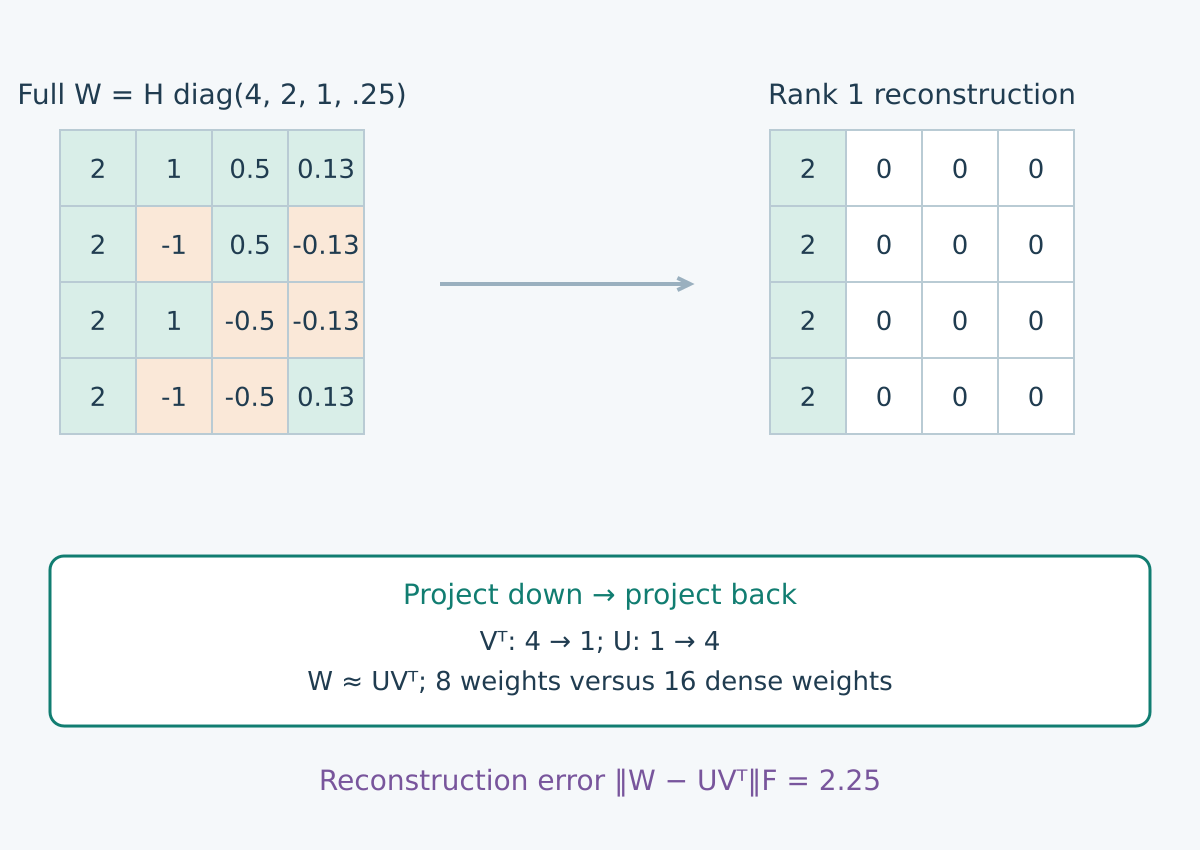

**Constructed SVD illustration.** Singular values are 4,2,1,.25. Rank one retains one direction, uses 8 matrix weights instead of 16, and discards Frobenius norm 2.25. Matrix error is not test loss.

In [ ]:
# TODO — Task 2: reduce, expand, apply the anchored update
def lowrank_step(x0, x, u, v, bias):
    hidden = ____
    mixture = ____
    return ____

In [ ]:
# CHECK — exact factor identity and autograd
u=torch.tensor([[1.],[2.]],dtype=torch.float64,requires_grad=True)
v=torch.tensor([[3.],[-1.]],dtype=torch.float64,requires_grad=True)
factored=lowrank_step(x0,x,u,v,b)
expected=cross_step(x0,x,u@v.T,b)
check('Dense/factored identity',torch.allclose(factored,expected),'U and V both have shape [d,r]; track the transposes.')
check('Factor derivatives',torch.autograd.gradcheck(lowrank_step,(x0,x,u,v,b)),
      'Use tensor operations that preserve gradients.')
check('Weight-count boundary',2*64*8<64**2 and 2*64*32==64**2,'Count both factors; biases cancel in this comparison.')

In [ ]:
# PROVIDED — SVD intervention, keeping the input and dense weights fixed
# Predict before running: must better matrix reconstruction guarantee better test accuracy?
torch.manual_seed(48)
W=torch.randn(6,6,dtype=torch.float64)
left,singular,right=torch.linalg.svd(W,full_matrices=False)
probe=torch.randn(8,6,dtype=torch.float64)
bias=torch.zeros(6,dtype=torch.float64)
reference=cross_step(probe,probe,W,bias)
svd_rows=[]
for rank in (1,2,3,6):
    U=left[:,:rank]*singular[:rank]
    V=right[:rank].T
    approx=lowrank_step(probe,probe,U,V,bias)
    svd_rows.append({'Rank':rank,'Matrix weights':2*6*rank,
                     'Matrix error':float(torch.linalg.norm(W-U@V.T)),
                     'Max output change':float((approx-reference).abs().max())})
display(pd.DataFrame(svd_rows))
check('Full-rank reconstruction',svd_rows[-1]['Max output change']<1e-12,
      'Retaining every singular direction must recover the same linear map.')

## 4 · Task 3 — route the deep branch correctly (Fig.1)

**Goal:** return the representation consumed by the final head.
**Why:** stacked and parallel are distinct architectures even when all layer names look right.
**Hint boundary:** in stacked mode the MLP reads the crossed state; in parallel mode it reads the original state and its result joins the crossed state along the feature dimension. The MLP-only control reads the original state.

An MLP alternates affine maps with ReLU, `max(0,z)`. The head maps its input to one **logit**; sigmoid turns a logit into a probability. During training, binary cross-entropy on logits implements log loss stably. It penalizes confident wrong probabilities more strongly than uncertain ones.

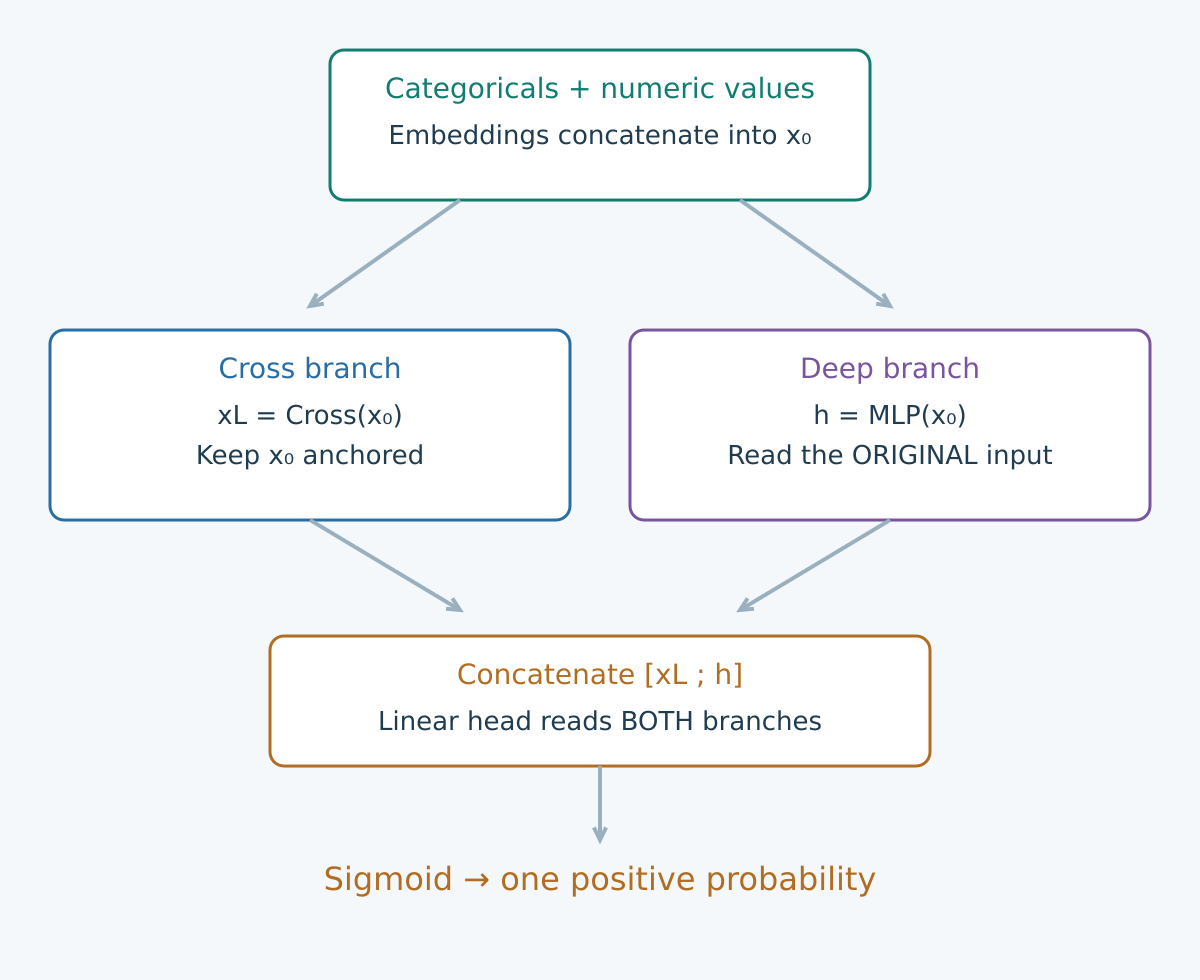

**Parallel:** both branches read x₀. The final head receives the concatenation `[crossed ; deep(original)]`. Our local and MovieLens trained models use this layout.

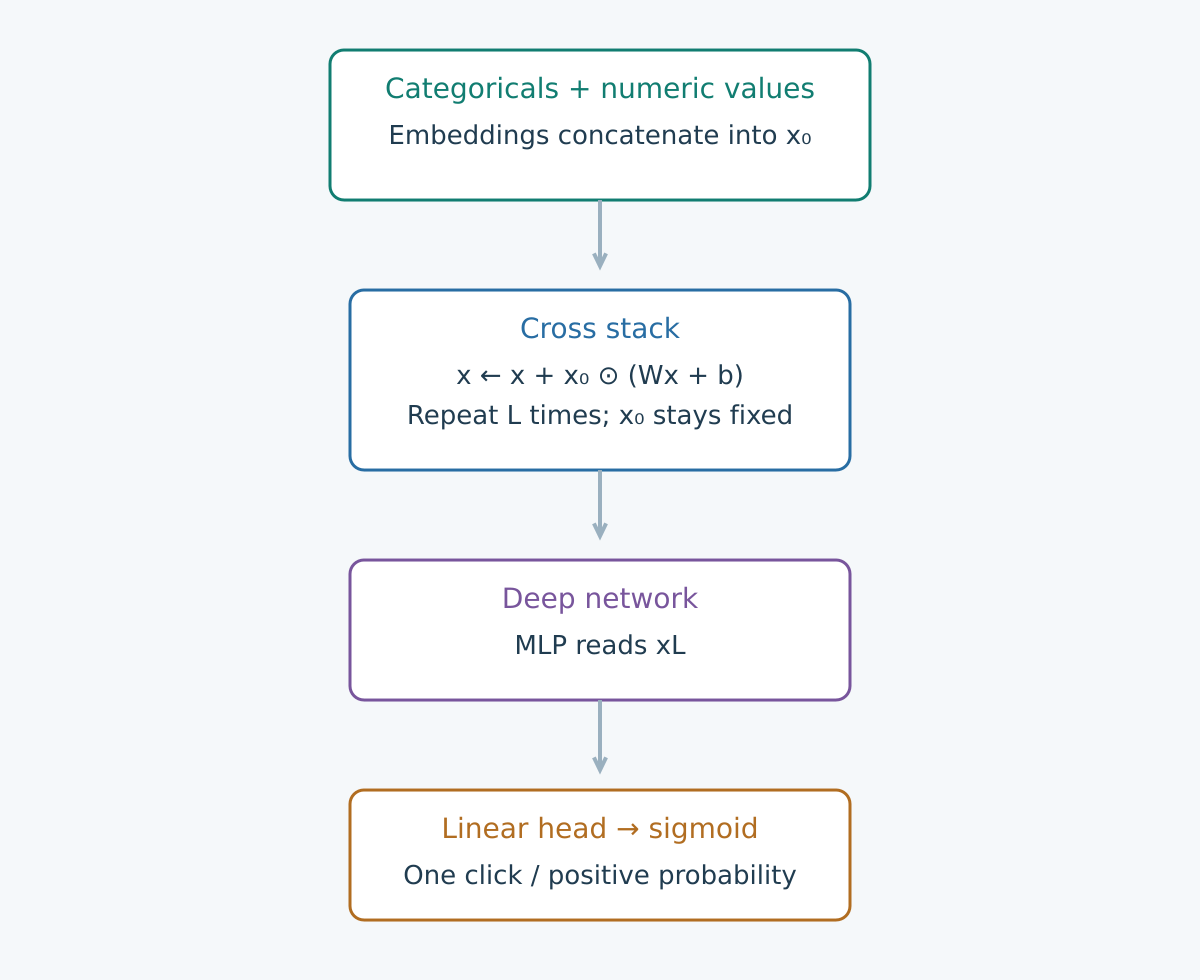

**Stacked:** the MLP reads the output of the cross network. The same train loop can optimize it, but that alone does not establish which layout performs better.

In [ ]:
# TODO — Task 3: distinguish the two data paths
def combine_paths(x0, crossed, deep, layout):
    if layout == 'stacked':
        return ____
    if layout == 'parallel':
        return ____
    if layout == 'mlp':
        return deep(x0)
    raise ValueError('Unknown layout')

In [ ]:
# CHECK — unequal branch widths make a wrong concat axis detectable
class ProbeDeep(nn.Module):
    def forward(self,z):
        self.seen=z.clone()
        return z.sum(dim=1,keepdim=True)
deep=ProbeDeep()
a=torch.tensor([[1.,2.],[3.,4.]])
crossed=torch.tensor([[5.,6.],[7.,8.]])
parallel=combine_paths(a,crossed,deep,'parallel')
check('Parallel original input',torch.equal(deep.seen,a),'The MLP must read x0 in parallel mode.')
check('Parallel feature concat',torch.equal(parallel,torch.tensor([[5.,6.,3.],[7.,8.,7.]])),
      'Keep batch size fixed; concatenate along the final feature dimension.')
stacked=combine_paths(a,crossed,deep,'stacked')
check('Stacked crossed input',torch.equal(deep.seen,crossed) and stacked.shape==(2,1),
      'The stacked MLP reads xL and supplies its output directly.')

## 5 · Task 4 — mix nonlinear expert updates (Eqs.3–4)

**Goal:** normalize gates across experts, weight their updates, and add the residual once.
**Why:** a low-rank linear layer and a nonlinear mixture are not interchangeable function classes.
**Hint boundary:** `experts` below has shape `[B,K,d]`, while gate logits have shape `[B,K]`. The expert axis is K. The residual is the current state, `[B,d]`.

Each expert first projects x down with $V_k^\top$, applies tanh, applies a learned r-by-r map $C_k$, applies tanh again, and expands with $U_k$. Tanh smoothly bounds each transformed coordinate between −1 and 1. Multiplication by $x_0$ produces an **update**, not a full residual output. Softmax turns learned gate logits into nonnegative weights summing to one for each row. This selected variant uses tanh/softmax and a shared bias; the paper allows other gates and activations.

In `einsum`, b labels rows, k experts, d original coordinates, and r/s latent coordinates. A repeated letter absent from the output is summed over. The provided projection lines implement the experts; you write the aggregation. Because the gate depends on x and the experts use tanh, the simple L+1 polynomial bound no longer applies.

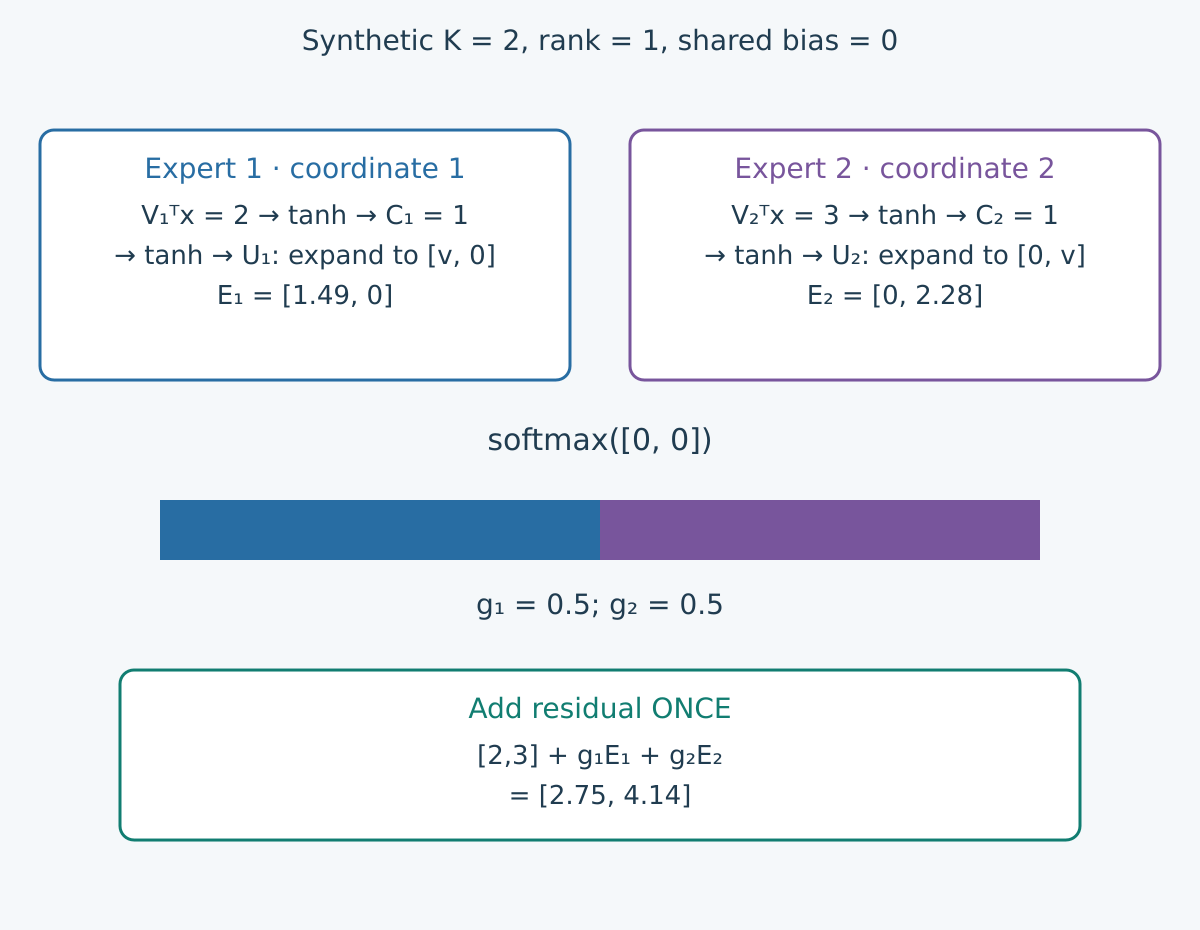

**Mechanism illustration:** gate logits `[0,0]` give weights `[.5,.5]`. Experts produce `[1.49,0]` and `[0,2.28]`, then one residual addition gives about `[2.75,4.14]`. The displayed values are rounded. This is not a measured DCN-Mix benchmark.

In [ ]:
# TODO — Task 4: expert computations provided; complete the gate and aggregation
def mix_step(x0, x, u, v, c, bias, gate_logits):
    """Eqs. 3–4, chosen tanh activation and normalized softmax gates.

    u,v: [K,d,r]; c: [K,r,r]; shared bias: [d]; gate_logits: [B,K].
    The paper also allows other gates/activations; this is one stated variant.
    """
    hidden = torch.tanh(torch.einsum('bd,kdr->bkr', x, v))
    hidden = torch.tanh(torch.einsum('bkr,ksr->bks', hidden, c))
    experts = x0[:, None, :] * (torch.einsum('bkr,kdr->bkd', hidden, u) + bias)
    gates = ____
    return ____

In [ ]:
# CHECK — explicit values, residual accounting, and gradients
z=torch.tensor([[2.,3.]],dtype=torch.float64,requires_grad=True)
U=torch.tensor([[[1.],[0.]],[[0.],[1.]]],dtype=torch.float64,requires_grad=True)
V=U.detach().clone().requires_grad_()
C=torch.ones(2,1,1,dtype=torch.float64,requires_grad=True)
zero=torch.zeros(2,dtype=torch.float64,requires_grad=True)
logits=torch.zeros(1,2,dtype=torch.float64,requires_grad=True)
answer=mix_step(z,z,U,V,C,zero,logits)
check('Equal-gate mixture',torch.allclose(answer,torch.tensor([[2.7460679984,4.1392654466]],dtype=torch.float64),atol=1e-8),
      'Normalize across experts, weight their updates, and add the original residual once.')
check('Mixture zero-update identity',torch.equal(mix_step(z,z,U*0,V,C,zero,logits),z),
      'With zero expert updates only one copy of the current state remains.')
check('Mixture derivatives',torch.autograd.gradcheck(mix_step,(z,z,U,V,C,zero,logits)),
      'Use differentiable projections and gate weights; check the expert axis.')

## 6 · The visible model that calls your functions

Read these short pieces in order. The cross module dispatches to **your** dense, factorized, or mixture function. The embedding module concatenates category vectors with numeric values. The top-level model preserves x₀ across every cross layer and calls **your** branch-combination function. No packaged DCNv2 model replaces your implementation.

**Source choices:** paper Eq.1/Eq.2 correspond to TFRS `Cross.call` with identity preactivation and diagonal scale zero. The pinned release names its two Dense factors differently; our U/V names follow the paper's column-vector equation. The source audit executed the literal released call method through torch-backed Dense adapters and checked outputs/gradients. This is a wiring check, not a TensorFlow-runtime or end-to-end training reproduction.

In [ ]:
# PROVIDED — Eqs.1–4: parameter ownership; forward dispatches to your task functions
class CrossLayer(nn.Module):
    """Choose a dense matrix, linear factorization, or nonlinear experts."""
    def __init__(self, d, kind='dense', rank=4, experts=2):
        super().__init__()
        if kind not in ('dense', 'lowrank', 'mix'):
            raise ValueError('Unknown cross kind')
        if not 1 <= rank <= d:
            raise ValueError('rank must be between 1 and input width')
        self.kind = kind
        self.bias = nn.Parameter(torch.zeros(d))
        if kind == 'dense':
            self.weight = nn.Parameter(torch.empty(d, d))
            nn.init.kaiming_normal_(self.weight)
        elif kind == 'lowrank':
            self.u = nn.Parameter(torch.empty(d, rank))
            self.v = nn.Parameter(torch.empty(d, rank))
            nn.init.xavier_normal_(self.u)
            nn.init.xavier_normal_(self.v)
        else:
            self.u = nn.Parameter(torch.empty(experts, d, rank))
            self.v = nn.Parameter(torch.empty(experts, d, rank))
            self.c = nn.Parameter(torch.empty(experts, rank, rank))
            self.gate = nn.Linear(d, experts, bias=False)
            for stack in (self.u, self.v, self.c):
                for matrix in stack:
                    nn.init.xavier_normal_(matrix)

    def forward(self, x0, x):
        if self.kind == 'dense':
            return cross_step(x0, x, self.weight, self.bias)
        if self.kind == 'lowrank':
            return lowrank_step(x0, x, self.u, self.v, self.bias)
        return mix_step(x0, x, self.u, self.v, self.c, self.bias, self.gate(x))

### Embeddings: define what one coordinate means

Vocabulary code zero is reserved for missing or unseen categories. Numeric features are standardized using training means and standard deviations; missing standardized values become zero. All vocabulary fitting lives in the provided data loader and is recorded in the split metadata. Category ID values only index embeddings.

In [ ]:
# PROVIDED — §3.1: one flat row representation, no CLS and no row attention
class RowEmbedding(nn.Module):
    """§3.1: concatenate categorical embeddings and normalized numerics.

    Vocabulary code 0 represents missing/unseen categories. No labels enter.
    No learned numeric token or CLS token: x0 is one flat vector per row.
    """
    def __init__(self, n_num, cards, embedding_dim=4):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(n, embedding_dim) for n in cards])
        self.d = n_num + len(cards) * embedding_dim

    def forward(self, xn, xc):
        pieces = [emb(xc[:, j]) for j, emb in enumerate(self.embeddings)]
        pieces.append(torch.nan_to_num(xn))  # standardized training mean = 0
        return torch.cat(pieces, dim=-1)

### Full forward path: do not move the anchor

Start with x=x₀. Each cross reads both the original x₀ and the current x. The branch-combination task chooses what the head reads. The MLP-only control constructs no cross layers. Cross counts, hidden widths and layouts are constructor arguments, so their changes are visible in the experiment record.

In [ ]:
# PROVIDED — Fig.1: complete supervised model with live task functions
class DCNv2(nn.Module):
    """Full supervised model; same embedding and MLP defaults across local arms."""
    def __init__(self, n_num, cards, embedding_dim=4, depth=2,
                 hidden=(32, 32), kind='dense', rank=4, experts=2, layout='parallel'):
        super().__init__()
        self.layout = layout
        self.embedding = RowEmbedding(n_num, cards, embedding_dim)
        d = self.embedding.d
        self.crosses = nn.ModuleList([] if layout == 'mlp' else
                                    [CrossLayer(d, kind, min(rank, d), experts) for _ in range(depth)])
        sizes = [d, *hidden]
        self.deep = nn.Sequential(*[layer for a, b in zip(sizes[:-1], sizes[1:])
                                    for layer in (nn.Linear(a, b), nn.ReLU())])
        self.head = nn.Linear(sizes[-1] + (d if layout == 'parallel' else 0), 1)
        for layer in [*self.deep, self.head]:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, xn, xc):
        x0 = self.embedding(xn, xc)
        x = x0
        for layer in self.crosses:
            x = layer(x0, x)  # original x0 is anchored across ALL layers
        return self.head(combine_paths(x0, x, self.deep, self.layout)).squeeze(-1)

In [ ]:
# CHECK — model forward actually invokes the student dense function
# A temporary counting wrapper provides evidence; it is restored immediately.
student_dense=cross_step
calls=[]
def counted_dense(*args):
    calls.append(tuple(args[0].shape))
    return student_dense(*args)
cross_step=counted_dense
try:
    torch.manual_seed(48)
    live_model=DCNv2(2,[4],embedding_dim=3,depth=2,hidden=(8,),layout='parallel')
    live_output=live_model(torch.ones(3,2),torch.tensor([[0],[1],[2]]))
    live_output.sum().backward()
finally:
    cross_step=student_dense
check('Student implementation on model path',len(calls)==2 and live_output.shape==(3,),
      'Every cross layer must call the notebook function, not a hidden packaged copy.')
check('Cross weights trainable',all(p.grad is not None and torch.isfinite(p.grad).all() for p in live_model.crosses.parameters()),
      'The loss must reach each cross parameter.')

### Inspect a real row before training

The next cell loads `credit_g`, preserves train/validation/test row IDs, and builds a small model. Inspect the embedding width and the norms after each cross layer. A norm is the square root of the sum of squared coordinates. Unexpectedly large norms can reveal numerical scaling problems, but a large norm alone is not evidence of good or bad prediction.

**Predict:** does multiplying by x₀ make the representation sensitive to how numeric fields were scaled? Explain why training-only scaling belongs in the protocol.

In [ ]:
# PROVIDED — real-data trace, no targets passed into forward
frame=prepare('credit_g',split_seed=5)
torch.manual_seed(48)
trace_model=DCNv2(frame['xn'].shape[1],frame['cards'])
ids=frame['train'][:3]
numeric=torch.tensor(frame['xn'][ids]);category=torch.tensor(frame['xc'][ids])
with torch.no_grad():
    original=trace_model.embedding(numeric,category)
    state=original
    trace=[{'Stage':'embedding','Shape':str(tuple(state.shape)),'Mean row norm':float(state.norm(dim=1).mean())}]
    for layer_no,layer in enumerate(trace_model.crosses,1):
        state=layer(original,state)
        trace.append({'Stage':f'cross {layer_no}','Shape':str(tuple(state.shape)),'Mean row norm':float(state.norm(dim=1).mean())})
display(pd.DataFrame(trace))
check('Split disjointness',not(set(frame['train'])&set(frame['test'])) and not(set(frame['valid'])&set(frame['test'])),
      'Held-out rows cannot appear in the fitting partitions.')
print('Train-only preprocessing:',frame['meta']['numeric_columns'],frame['meta']['categorical_columns'])

### Visible inference and training

Inference evaluates rows independently in batches. Training uses Adam, which adapts step sizes using running gradient statistics. Gradient clipping caps the joint gradient norm at 10 to limit extreme updates. An **epoch** visits the training rows once; a **checkpoint** is a saved parameter state. The validation log loss, not test AUROC, selects the checkpoint.

Read the loop: shuffle training indices using the model seed, clear gradients, compute logits, compute loss, backpropagate, clip and update. After each epoch evaluate validation rows and copy the best state. The optional **EMA** shadow averages parameters over updates; it is off in the learning lab and closer preset, on in the larger paper preset. Returning the selected model makes selection explicit.

In [ ]:
# PROVIDED — inference: per-row sigmoid probabilities, no labels
@torch.no_grad()
def predict_dcn(model, xn, xc, batch_size=1024):
    model.eval()
    device = next(model.parameters()).device
    chunks = []
    for start in range(0, len(xn), batch_size):
        a = torch.as_tensor(xn[start:start+batch_size], dtype=torch.float32, device=device)
        b = torch.as_tensor(xc[start:start+batch_size], dtype=torch.long, device=device)
        chunks.append(model(a, b).sigmoid().cpu().numpy())
    return np.concatenate(chunks)

In [ ]:
# PROVIDED — visible optimization, optional EMA, and validation-only checkpoint selection
def train_dcn(model, xn, xc, y, train, valid, seed=0, epochs=20,
              batch_size=64, lr=.001, weight_decay=0., device='cpu', ema_decay=None):
    """Visible train loop. Select on VALIDATION log loss; no test labels here.

    Local default: Adam, fixed epochs, no EMA. The MovieLens track uses optional
    parameter EMA (0.9999): optimization updates raw weights, validation selects
    EMA snapshots. A completed run returns the selected inference weights.
    """
    from sklearn.metrics import log_loss
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model.to(device)
    numeric = torch.as_tensor(xn, dtype=torch.float32, device=device)
    category = torch.as_tensor(xc, dtype=torch.long, device=device)
    target = torch.as_tensor(y, dtype=torch.float32, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    ema = copy.deepcopy(model) if ema_decay is not None else None
    best_loss, best, history = float('inf'), None, []
    for epoch in range(1, epochs+1):
        model.train()
        order = rng.permutation(train)
        total = 0.
        for start in range(0, len(order), batch_size):
            ids = torch.as_tensor(order[start:start+batch_size], device=device)
            optimizer.zero_grad(set_to_none=True)
            loss = F.binary_cross_entropy_with_logits(model(numeric[ids], category[ids]), target[ids])
            if not torch.isfinite(loss):
                raise FloatingPointError('Non-finite loss; inspect scaling and cross activations.')
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 10.)
            optimizer.step()
            total += float(loss.detach()) * len(ids)
            if ema is not None:
                with torch.no_grad():
                    for shadow, parameter in zip(ema.parameters(), model.parameters()):
                        shadow.mul_(ema_decay).add_(parameter, alpha=1-ema_decay)
        inference = model if ema is None else ema
        p = predict_dcn(inference, xn[valid], xc[valid])
        score = float(log_loss(y[valid], p, labels=[0, 1]))
        history.append({'epoch': epoch, 'train_loss': total/len(train), 'valid_loss': score})
        if score < best_loss:
            best_loss = score
            best = {k: v.detach().cpu().clone() for k, v in inference.state_dict().items()}
    model.load_state_dict(best)
    model.eval()
    return model, history

## 7 · Train the comparison using your implementation

**Predict before running:** which table might favor a smaller factorization? What would count as evidence against the claim that dense crosses must win?

**Your prediction:** _write here._

We vary the architecture, holding split seed 5, preprocessing, and neural training budgets fixed. MLP, dense-cross and factored-cross arms use embedding width 4 and MLP `[32,32]`; cross arms have two layers. Rank is `min(4,max(1,d//4))`, deliberately below half the input width for these tables. Three model seeds (0,1,2) vary initialization and training order. Each neural run gets 20 epochs at batch 64 and Adam learning rate .001. CatBoost gets a separate untuned 300-iteration budget, depth 6, learning rate .05. Every arm selects on validation log loss. Test labels only score the chosen models.

Parameter counts are unequal. Factors use a different initialization from dense matrices. Thus this is a comparison under a shared procedure, not a clean causal estimate of rank alone. The three real tables are substitutes for the paper's MovieLens/Criteo data. Log loss is recorded along with AUROC; the rank summary uses AUROC, declared before the table appears.

In [ ]:
# PROVIDED — the harness receives YOUR model and visible trainer/predictor
from _verify_l048 import run as run_comparison
result=run_comparison(model_cls=DCNv2,train_fn=train_dcn,predict_fn=predict_dcn)
labels={'mlp':'MLP','dense':'Dense cross + MLP','lowrank':'Factored cross + MLP','catboost':'CatBoost'}
display(score_table(result,labels).round(5))
plot_scores(result,labels);plt.show()
plot_ranks(result,labels);plt.show()
print('Runtime:',round(result['wall_s'],2),'seconds')

In [ ]:
# CHECK — evidence shape, valid probabilities/scores, and independent-row probe
check('Three real datasets',len(result['results']['per_dataset'])==3,'Comparative claims require multiple tables.')
check('Three seeds per arm',all(len(a['scores'])==3 for arms in result['results']['per_dataset'].values() for a in arms.values()),
      'Keep variability; do not report only the winning seed.')
check('Finite AUROC',all(np.isfinite(a['scores']).all() and all(0<=x<=1 for x in a['scores']) for arms in result['results']['per_dataset'].values() for a in arms.values()),
      'Investigate non-finite predictions or a broken metric.')
batch_change=max(v['max_batch_change'] for v in result['diagnostics'].values())
check('Rows independent at inference',batch_change<1e-5,
      'Only tiny kernel-roundoff differences should remain; there is no row attention or batch normalization.')
display(pd.DataFrame(result['diagnostics']).T[['parameters','best_epoch','max_batch_change']])
print('Maximum batch-size numerical change:',batch_change)

### How to read the plots

AUROC is a ranking metric: the probability that a positive receives a higher score than a negative, with ties counted as half. Log loss assesses the probability assigned to the true class. The plots show each seed, a mean diamond, and ±1 sample standard deviation (SD). SD measures spread; it is not a confidence interval. The report's 95% intervals use a t multiplier and describe seed variability **conditional on the fixed split**.

The rank plot first ranks each table's seed means, then averages ranks across the three datasets. The Friedman test looks for an overall model-rank difference. The Nemenyi critical difference sets a threshold for pairwise mean-rank gaps. A large p-value means no detected overall difference under this small experiment; it does not establish model equivalence. With only three datasets, these asymptotic tests have low power and are a rough diagnostic.

Below is the independently recorded author run. Use it to practice interpretation, not as a target that your code must force itself to match.

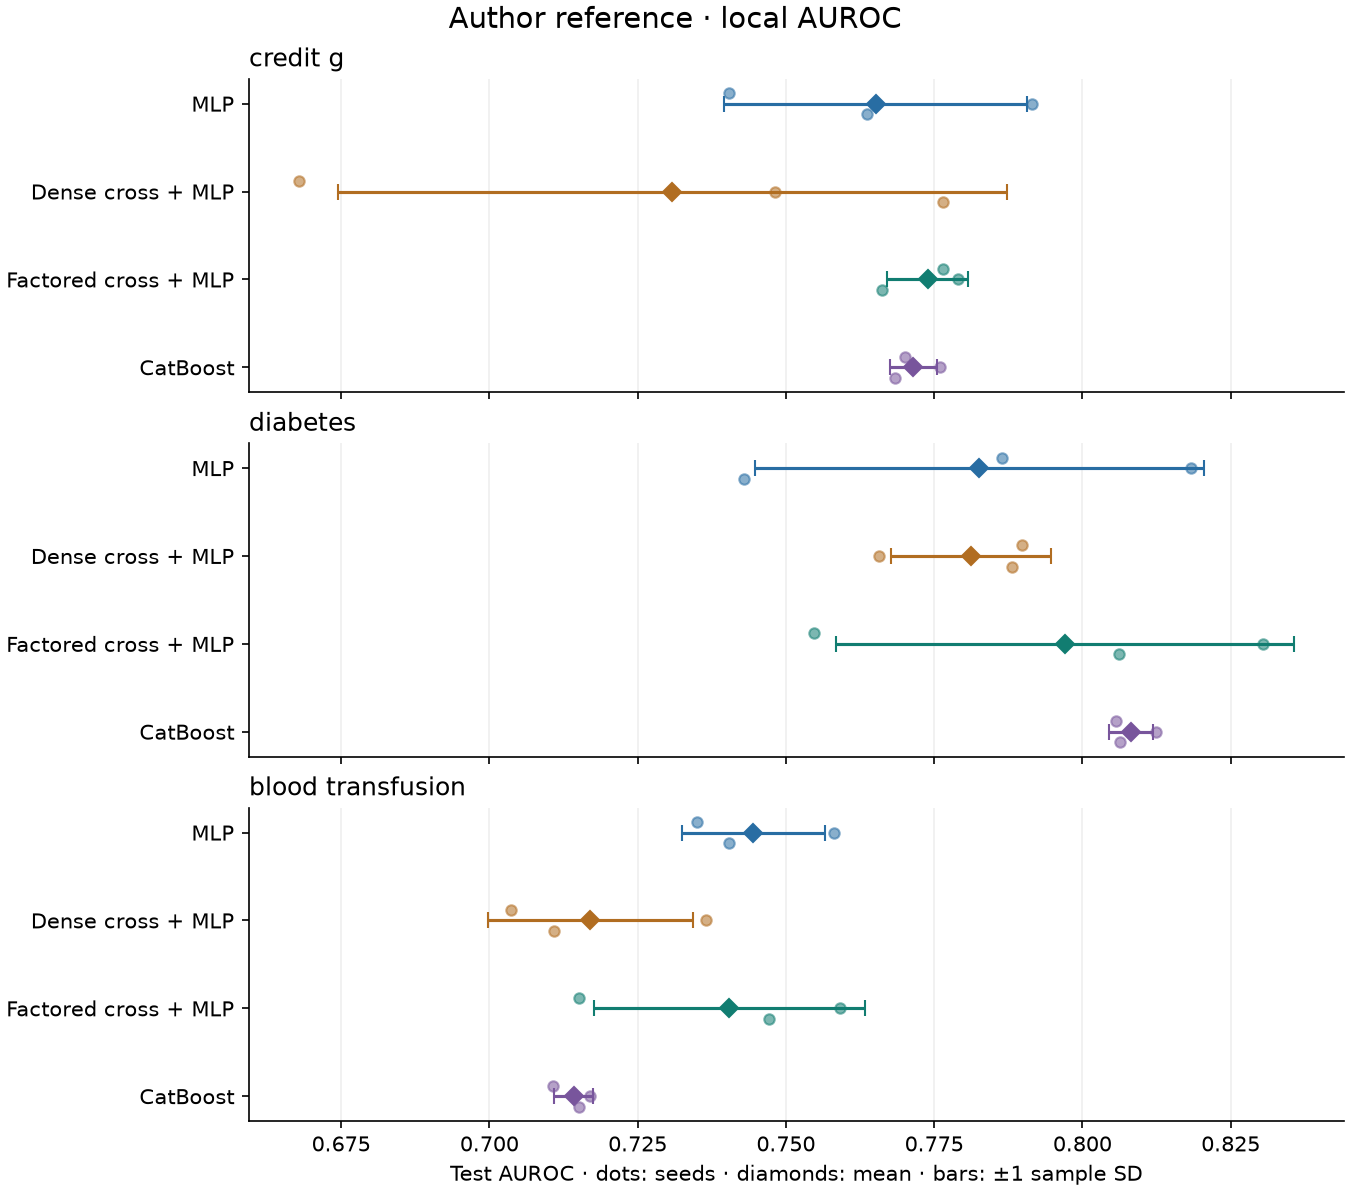

**Author reference, separate from your current result.** Factored crosses lead credit_g, CatBoost leads diabetes, and MLP leads blood_transfusion. Dense crosses show substantial seed variability on credit_g. No universal winner is inferred from this small sample.

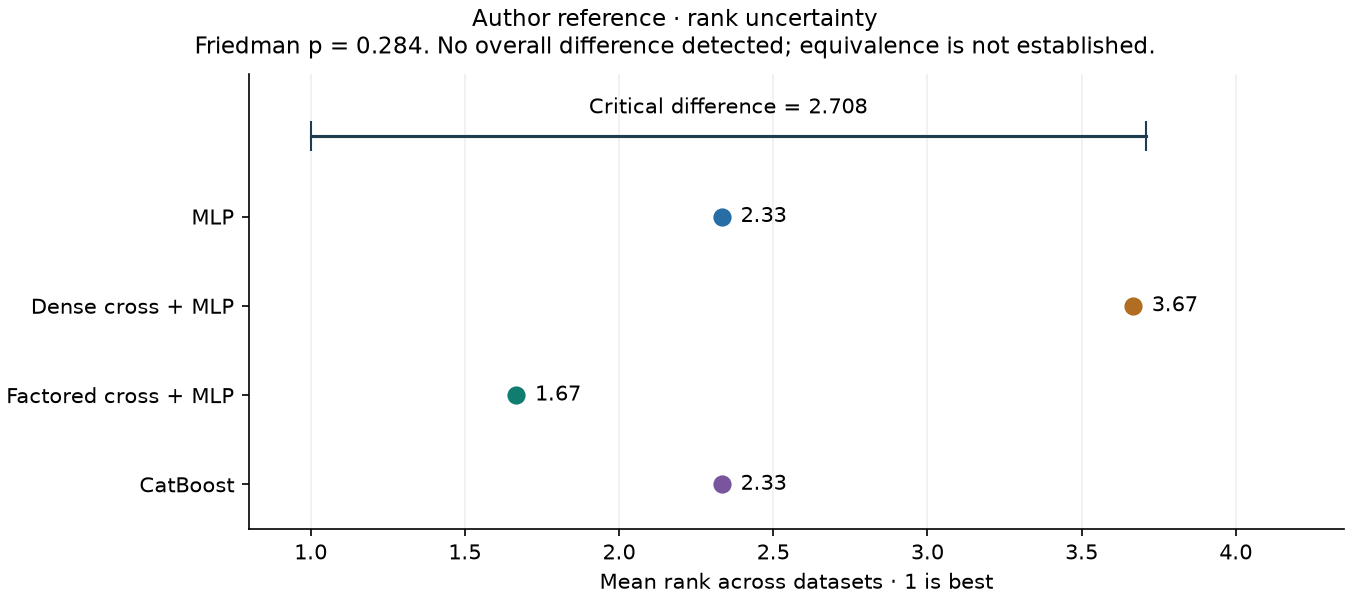

**Author reference.** Mean ranks: MLP 2.333, dense 3.667, factored 1.667, CatBoost 2.333. Friedman p=.284; CD=2.708; no overall difference detected, not proof of equivalence. Source: `_verify_l048_results.json`.

**Interpret your evidence:** name one per-table observation, one plausible alternative explanation, and one conclusion this experiment cannot establish. Explain why a smaller factored model doing well would not prove that post-training SVD compression is harmless.

**Your interpretation:** _write here._

## 8 · The full-data paper-results attempt

The paper's MovieLens task drops rating 3 and maps ratings 1/2→0, 4/5→1. It reports log loss and AUROC on random 80/10/10 splits. The TensorFlow tutorial predicts raw ratings and reports RMSE; that is a different target and metric.

Our six categorical fields are user ID, movie ID, gender, age, occupation and ZIP. The paper does not enumerate the exact six-field mapping in the inspected text, so this is a recorded interpretation. Genre is multivalued and omitted; rating and timestamp are not inputs. A random interaction split can share users/movies across folds. It measures neither cold-start generalization nor point-in-time forecasting.

**We ran the closer track on all 739,012 filtered rows, across three seeds.** It used dense parallel DCNv2, 16-wide category embeddings, two cross layers, MLP `[128,128]`, five epochs, Adam at .001, batch 128, and validation log-loss selection. Test log loss was **0.355545 ± 0.000692**, AUROC **0.864981 ± 0.000413**, with SD across three seeds. Training took about 204 seconds on an aarch64 CPU.

The cited Table 6 DCN-V2 values are log loss **0.3170 ± 0.00036** and AUROC **0.8950 ± 0.00027**, over five runs. Our result remains **INCOMPARABLE** as an exact reproduction: original split IDs and MovieLens winning settings are unavailable, our budget/settings differ, and no exhaustive tuning was performed. A protocol mismatch prevents interpreting a near or distant number as MATCH or FAIL. DCN-Mix, Criteo, and the private production result are not reproduced.

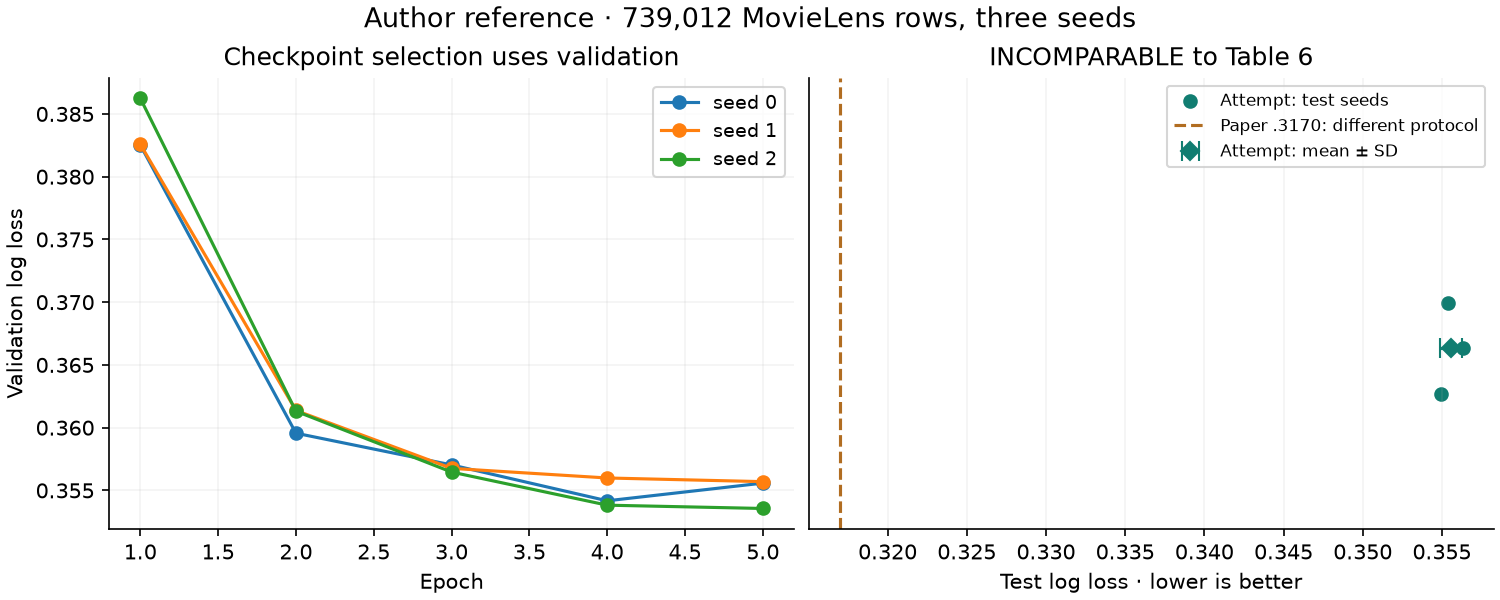

**Measured author reference.** Left is validation checkpoint selection; right is held-out log loss. The paper marker is from a different protocol. Sources: `_scaleup_l048_results.json` and `_scaleup_l048_manifest.json`. The broader paper preset remains NOT_RUN.

## EXIT TICKET · evidence plus explanation

Before printing the numerical ticket, write these in your own words:

1. Explain the original-input anchor and compute two scalar layers at x=2, w=1, b=0.
2. State the degree bound and the conditions under which it stops applying.
3. Give a d/r example that saves weights and one that does not.
4. Explain your rank table without conflating “not detected” with “equivalent.”
5. Explain why our full MovieLens run is INCOMPARABLE to Table 6, even though it uses the paper dataset and core operation.

**Your explanation:** _write here. Paste it with the numerical ticket to the teacher for review; passing Python assertions cannot grade these claims._

In [ ]:
# EXIT — your measured outputs; do not replace them with author-reference numbers
check('All previous checks pass',all(checks.values()),'Resolve each failing CHECK before interpreting results.')
exit_ticket={'lesson':48,'checks_passed':sum(checks.values()),'checks_total':len(checks),
             'local_mean_ranks':result['results']['mean_ranks'],
             'friedman':result['results']['friedman'],'nemenyi_cd':result['results']['nemenyi_cd'],
             'max_batch_probability_change':batch_change,'model_seeds':result['seeds'],
             'split_seed':result['config']['split_seed'],
             'scope':result['scope'],'paper_result_status':'See separate scale-up ledger; not inferred from local ranks.'}
print(json.dumps(exit_ticket,indent=2))

## REQUIRED NEXT STEP · audit and run the MovieLens track

The larger runner is visible below and calls the same model and training loop you just read. Data loading is reusable plumbing in `relkit/dcnv2_data.py`; the source card documents fields, checksums and splits. The gate is off by default so opening a notebook does not launch a larger experiment.

| Preset | Data / seeds / epochs | Main settings | Status in author package |
|---|---|---|---|
| smoke | 2,000 rows / 1 / 1 | embedding 4, MLP [16,16] | Pipeline tested; no score claim |
| closer | full filtered data / 3 / 5 | embedding 16, MLP [128,128], no EMA | Executed; INCOMPARABLE |
| paper | full filtered data / 5 / 20 | embedding 30, MLP [128,128], EMA .9999 | NOT_RUN; some choices remain unreported by the paper |

All presets use dense parallel crosses (depth 2), batch 128, and chosen learning rate .001. “paper” names a larger attempt, not a certification that unknown MovieLens settings have been recovered. Match the protocol before interpreting an absolute tolerance of .001 around the cited log loss.

**Colab:** choose a persistent Drive output directory below; enable `RUN_PAPER_REPRO`. The local CPU route also works. For an unattended GPU run: `modal run --detach modal/l048_paper_repro.py --preset closer`. The Modal/Colab GPU paths are supplied but were not executed by the author. If GroupLens has a certificate problem, supply a separately downloaded checksum-verified `ml-1m.zip` via `ARCHIVE_PATH`; the loader will not silently disable TLS.

The manifest binds code, data, settings, device and notebook implementation digest. Completed seeds resume; incomplete seeds restart. Change the output directory when you change the protocol. Keep `protocol.json`, manifests, weights, test predictions, histories and the ledger together. Do not upload raw user-level prediction artifacts as part of a public course commit.

In [ ]:
# PROVIDED — the scale-up runner's dependencies and explicitly named presets
import argparse
from relkit.dcnv2_data import load_movielens
from relkit.paper_repro import PaperTarget, LabFinding, ScaleUpRun, classify_number, format_ledger
PRESETS={
    'smoke':dict(cap=2000,seeds=[0],epochs=1,embedding_dim=4,hidden=[16,16],batch_size=128,lr=.001,ema_decay=None),
    'closer':dict(cap=None,seeds=[0,1,2],epochs=5,embedding_dim=16,hidden=[128,128],batch_size=128,lr=.001,ema_decay=None),
    'paper':dict(cap=None,seeds=[0,1,2,3,4],epochs=20,embedding_dim=30,hidden=[128,128],batch_size=128,lr=.001,ema_decay=.9999)}
DEVIATIONS=[
    'Original split indices/seeds unavailable; new fixed random 80/10/10 split, seed 48.',
    'Six fields interpreted as user, movie, gender, age, occupation, ZIP; train-only vocabularies.',
    'MovieLens-specific winning depth/MLP/LR/step count not disclosed in Table 6; chosen depth=2, parallel layout and fixed settings, no full hyperparameter search.',
    'PyTorch implementation and initialization details differ from the TensorFlow v1 experiments.',
    'Criteo and private production data are outside this attempt.']

### Visible runner: save provenance, train each seed, print the verdict

The loop below supplies only train/validation labels to the trainer, scores the saved model on test rows, and keeps paper and attempt values in separate ledger entries. `atomic_json` writes a temporary file before replacement so a partially written summary is not mistaken for a completed seed. The selected model weights and predictions are saved before the seed completion record.

Notebook source extraction changes only the runner name and the way it finds its source file; model/training computations are unchanged. The notebook passes a digest of its actual task functions and classes as implementation identity, so rerunning modified TODOs cannot silently reuse a prior implementation's completed seeds.

In [ ]:
# PROVIDED — visible paper-results loop; actual model and trainer remain those above
def atomic_json(path,value):
    temporary=path.with_suffix(path.suffix+'.tmp')
    temporary.write_text(json.dumps(value,indent=2)+'\n')
    temporary.replace(path)


def run_paper_results(preset='closer',output_dir='data/cache/l048-closer',archive_path=None,device='cpu',
        model_cls=DCNv2,train_fn=train_dcn,predict_fn=predict_dcn,implementation_id=None):
    torch.set_num_threads(1)
    if implementation_id is None and (model_cls is not DCNv2 or train_fn is not train_dcn or predict_fn is not predict_dcn):
        raise ValueError('Injected notebook implementations must supply their source digest as implementation_id.')
    start=time.time(); cfg=PRESETS[preset].copy()
    dest=Path(output_dir);dest.mkdir(parents=True,exist_ok=True)
    fr=load_movielens(archive_path,cap=cfg['cap'])
    meta=fr['meta']; protocol_hash=hashlib.sha256(json.dumps(meta,sort_keys=True).encode()).hexdigest()
    source=(LABS / "_paper_repro_l048.py").parent/'relkit/dcnv2.py'
    fingerprint={'preset':preset,'config':cfg,'protocol_sha256':protocol_hash,
                 'model_sha256':hashlib.sha256(source.read_bytes()).hexdigest(),
                 'implementation_id':implementation_id or 'canonical',
                 'data_loader_sha256':hashlib.sha256((source.parent/'dcnv2_data.py').read_bytes()).hexdigest(),
                 'runner_sha256':hashlib.sha256((LABS / "_paper_repro_l048.py").read_bytes()).hexdigest(),
                 'versions':environment(),'device':device}
    manifest=dest/'run_manifest.json'
    if manifest.exists() and json.loads(manifest.read_text())!=fingerprint:
        raise ValueError('Existing directory belongs to different code/data/config/device. Choose a new output directory.')
    atomic_json(manifest,fingerprint)
    atomic_json(dest/'protocol.json',meta)
    xn,xc,y,tr,va,te=[fr[k] for k in ('xn','xc','y','train','valid','test')]
    rows=[]
    for seed in cfg['seeds']:
        saved=dest/f'seed-{seed}.json'
        if saved.exists() and (dest/f'seed-{seed}.pt').exists() and (dest/f'seed-{seed}-predictions.npz').exists():
            rows.append(json.loads(saved.read_text()));print('Reusing completed seed',seed,flush=True);continue
        tick=time.time();torch.manual_seed(seed)
        model=model_cls(0,fr['cards'],embedding_dim=cfg['embedding_dim'],hidden=cfg['hidden'],
                        depth=2,kind='dense',layout='parallel')
        model,history=train_fn(model,xn,xc,y,tr,va,seed=seed,epochs=cfg['epochs'],
                               batch_size=cfg['batch_size'],lr=cfg['lr'],device=device,ema_decay=cfg['ema_decay'])
        p=predict_fn(model,xn[te],xc[te])
        row={'seed':seed,'logloss':float(log_loss(y[te],p,labels=[0,1])),
             'auroc':float(roc_auc_score(y[te],p)), 'wall_s':time.time()-tick,
             'parameters':sum(v.numel() for v in model.parameters()),'history':history}
        torch.save(model.state_dict(),dest/f'seed-{seed}.pt')
        np.savez_compressed(dest/f'seed-{seed}-predictions.npz',row_ids=np.asarray(meta['row_ids'])[te],target=y[te],probability=p)
        atomic_json(saved,row);rows.append(row)
        print('Completed',seed,'logloss',row['logloss'],'AUROC',row['auroc'],'seconds',row['wall_s'],flush=True)
    values=np.array([r['logloss'] for r in rows]);aucs=np.array([r['auroc'] for r in rows])
    deviations=DEVIATIONS+[f'Preset {preset}: {cfg}. Preset name does not certify protocol equality.']
    target=PaperTarget(paper='Wang et al. WWW 2021',arxiv='2008.13535v2',table='Table 6 DCN-V2',
                        dataset='MovieLens-1M',metric='logloss',paper_value=.3170,paper_std=.00036,
                        higher_is_better=False,abs_tol=.001,paper_split='random 80/10/10')
    attempt=ScaleUpRun(method='dense parallel DCNv2',dataset='MovieLens-1M',metric='logloss',
                      value=float(values.mean()),std=float(values.std(ddof=1)) if len(values)>1 else None,
                      n_seeds=len(rows),hardware=device+' / '+platform.machine(),wall_s=sum(r['wall_s'] for r in rows),
                      protocol_deviations=deviations,protocol_match=False)
    verdict=classify_number(target,attempt)
    ledger=format_ledger(title='L048 — MovieLens binary task',
                         lab=[LabFinding('Local comparison','see _verify_l048_results.json','Three substitute tables, fixed small budgets')],
                         paper=[(target,attempt,verdict)],extra_lines=['Also reported AUROC: '+str(float(aucs.mean()))])
    result={'preset':preset,'config':cfg,'rows':len(y),'seeds':rows,'mean_logloss':attempt.value,
            'sample_std_logloss':attempt.std,'mean_auroc':float(aucs.mean()),
            'sample_std_auroc':float(aucs.std(ddof=1)) if len(aucs)>1 else None,
            'verdict':verdict,'protocol_deviations':deviations,'ledger':ledger,
            'wall_s':time.time()-start,'training_wall_s':attempt.wall_s,
            'protocol_sha256':protocol_hash,'environment':environment()}
    atomic_json(dest/'summary.json',result);(dest/'ledger.txt').write_text(ledger+'\n')
    print(ledger,flush=True)
    return result

In [ ]:
# PROVIDED — gated larger run; author evidence is available even while this is off
RUN_PAPER_REPRO=False
PRESET='closer'
ARCHIVE_PATH=None  # optional existing, checksum-verified ml-1m.zip
if 'google.colab' in sys.modules and RUN_PAPER_REPRO:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR=Path('/content/drive/MyDrive/relational/l048')/PRESET
else:
    OUTPUT_DIR=LABS/'data/cache'/('l048-student-'+PRESET)

if RUN_PAPER_REPRO:
    live_symbols=[cross_step,lowrank_step,mix_step,combine_paths,CrossLayer,RowEmbedding,DCNv2,train_dcn,predict_dcn]
    live_source=[]
    for obj in live_symbols:
        members=[m for m in obj.__dict__.values() if inspect.isfunction(m)] if inspect.isclass(obj) else [obj]
        live_source.extend(inspect.getsource(m) for m in members)
    implementation_id=hashlib.sha256('\n'.join(live_source).encode()).hexdigest()
    scale_result=run_paper_results(preset=PRESET,output_dir=str(OUTPUT_DIR),archive_path=ARCHIVE_PATH,
                                  device='cuda' if torch.cuda.is_available() else 'cpu',
                                  model_cls=DCNv2,train_fn=train_dcn,predict_fn=predict_dcn,
                                  implementation_id=implementation_id)
    plot_scaleup(scale_result,title='Your run · MovieLens attempt');plt.show()
    print('Keep all artifacts in:',OUTPUT_DIR)
else:
    author=json.loads((LABS/'_scaleup_l048_results.json').read_text())
    print('YOUR scale-up: NOT_RUN in this kernel. AUTHOR closer run follows:')
    print(author['ledger'])
    print('Larger paper preset: NOT_RUN by the author. Set the gate deliberately when ready.')

### Follow up with your teacher

Paste your EXIT explanation and your scale-up ledger. Ask about the first tensor, equation, or protocol choice you cannot explain without reading. If your metric differs, keep the evidence and investigate the source of the discrepancy; a forced winning score is not the objective.

[Cross-network reference](../reference/dcnv2-reproduction.html) · [Authoritative glossary](../reference/glossary.html) · [Primary paper](https://arxiv.org/html/2008.13535v2) · [Official cross-layer implementation, pinned 0.7.3](https://github.com/tensorflow/recommenders/blob/v0.7.3/tensorflow_recommenders/layers/feature_interaction/dcn.py)